# Segmentations & Recommendations

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv('../data/processed/patient_journey.csv')
df.columns.to_list()

['Unnamed: 0',
 'patient_id',
 'inquiry_date',
 'country',
 'age_group',
 'gender',
 'treatment_category',
 'provider_id',
 'lead_source',
 'coordinator_id',
 'budget_band',
 'medical_urgency',
 'intent_score',
 'response_time_hours',
 'engagement_score',
 'consultation_booked',
 'quote_shared',
 'treatment_completed',
 'follow_up_completed',
 'current_stage',
 'drop_off_flag',
 'drop_off_stage',
 'reason_for_drop_off',
 'estimated_case_value_inr',
 'actual_revenue_inr',
 'service_cost_inr',
 'satisfaction_score']

## Patient Segmentation

In [4]:
segment_features = ['age_group', 'intent_score', 'engagement_score','response_time_hours', 'estimated_case_value_inr','medical_urgency', 'sla_breach']

numeric_cols = [
    'intent_score',
    'engagement_score',
    'response_time_hours',
    'estimated_case_value_inr'
]

categorical_cols = [
    'age_group',
    'medical_urgency'
]

In [6]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])
X_seg = preprocessor.fit_transform(df[numeric_cols + categorical_cols])

In [12]:
inertias, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_seg)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_seg, labels))

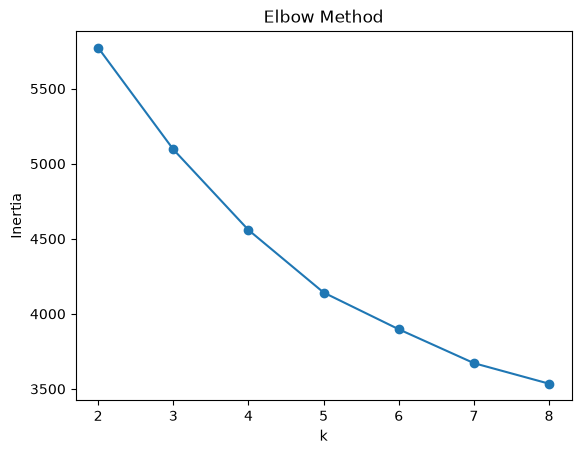

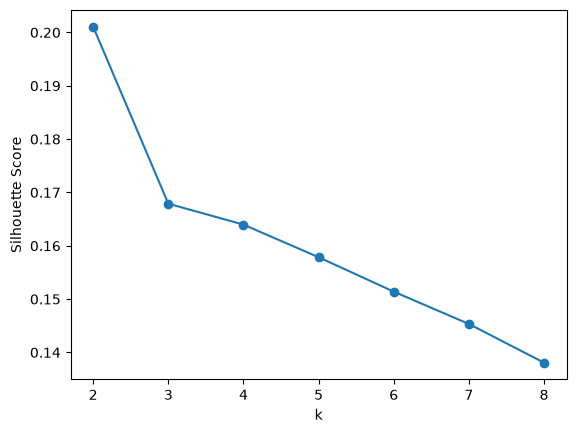

In [13]:
plt.plot(range(2,9), inertias, marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.show()

plt.plot(range(2,9), sil_scores, marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette Score')
plt.show()

Silhouette score of 0.20 at k=2 indicates two genuine but moderately overlapping segments, rather than sharply distinct clusters. This is expected for behavioral/engagement data, which tends to sit on a continuum rather than form naturally isolated groups. The segmentation is still directionally useful for prioritization, but should be treated as a soft grouping rather than a hard rule

In [17]:
final_k = 2
km_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['segment'] = km_final.fit_predict(X_seg)

In [22]:
# sla breach
country_ref = pd.read_csv('../data/processed/country_reference.csv')
df = df.merge(country_ref[['country', 'baseline_response_expectation_hours']], on='country', how='left')

df['sla_breach'] = df['response_time_hours'] > df['baseline_response_expectation_hours']


In [24]:
df.groupby('segment')[numeric_cols + ['treatment_completed', 'sla_breach']].mean()

,intent_score,engagement_score,response_time_hours,estimated_case_value_inr,treatment_completed,sla_breach
segment,,,,,,
0,48.823973,36.124658,19.163836,483110.606849,0.172603,0.890411
1,74.258961,69.089351,14.979221,443732.045455,0.555844,0.768831


In [25]:
df.groupby('segment')['medical_urgency'].value_counts(normalize=True)

segment  medical_urgency
0        Routine            0.401370
         Moderate           0.376712
         Urgent             0.221918
1        Moderate           0.432468
         Routine            0.381818
         Urgent             0.185714
Name: proportion, dtype: float64

### Patient Segments

**Segment 0 — Low-Engagement Risk Group (n=730, 48.7%)**
Lower intent and engagement scores, disproportionately fewer Urgent cases, 
very high SLA breach (89%), and low treatment completion (17.3%).
**Recommended action**: This group needs re-engagement tactics before 
SLA fixes will even matter — e.g. proactive outreach, simplified 
next-step messaging, or lead-scoring to deprioritize very low-intent 
inquiries rather than spending equal coordinator effort on them.

**Segment 1 — High-Value Engaged Group (n=770, 51.3%)**
Higher intent/engagement, more Moderate-urgency cases, and over 3x 
the completion rate of Segment 0 (55.6% vs 17.3%) despite still facing 
high SLA breach (76.9%).
**Recommended action**: This is the highest-ROI segment for SLA 
improvement — they're already engaged and likely to convert, so faster 
response times here would yield the most incremental completions. 
Fast-track this segment for priority coordinator response.

## Provider Preference

In [26]:
provider_perf = df.groupby('provider_id').agg(
    total_patients=('patient_id', 'count'),
    consultation_rate=('consultation_booked', 'mean'),
    treatment_rate=('treatment_completed', 'mean')
).sort_values('treatment_rate', ascending=False)
provider_perf

,total_patients,consultation_rate,treatment_rate
provider_id,,,
PVD-020,55,0.890909,0.527273
PVD-007,50,0.720000,0.520000
PVD-008,55,0.818182,0.509091
PVD-001,55,0.727273,0.472727
PVD-011,49,0.755102,0.469388
PVD-017,43,0.744186,0.465116
PVD-015,56,0.678571,0.464286
PVD-003,59,0.711864,0.440678
PVD-022,47,0.659574,0.425532


In [28]:
scaler = StandardScaler()
X_provider = scaler.fit_transform(provider_perf[['consultation_rate', 'treatment_rate', 'total_patients']])

In [29]:
inertias, sil_scores = [], []
for k in range(2, 6):  # smaller range since only 30 providers
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_provider)
    sil_scores.append(silhouette_score(X_provider, labels))
print(sil_scores)

[0.37940355132748443, 0.2787278117783976, 0.27749037361500906, 0.2642173031271546]


In [31]:
km_provider = KMeans(n_clusters=2, random_state=42, n_init=10)
provider_perf['segment'] = km_provider.fit_predict(X_provider)

provider_perf.groupby('segment')[['consultation_rate', 'treatment_rate', 'total_patients']].mean()

,consultation_rate,treatment_rate,total_patients
segment,,,
0,0.717068,0.425012,53.352941
1,0.562128,0.288496,45.615385


### Provider Segments

**Segment 0 — High-Performing Providers (n=17)**
Consultation rate 71.7%, treatment completion 42.5%, average caseload 53 patients.
**Recommended action**: Study these providers' operational practices 
(response speed, follow-up cadence) as a best-practice benchmark. 
Consider directing higher-value or higher-urgency referrals here given 
demonstrated ability to convert.

**Segment 1 — Underperforming Providers (n=13)**
Consultation rate 56.2%, treatment completion 28.8%, average caseload 46 patients.
**Recommended action**: [If urgency check shows they handle more Urgent 
cases] — Performance gap partially reflects harder case mix; recommend 
case-mix-adjusted review before punitive action, paired with targeted 
support (faster SLA compliance, dedicated coordinator support) for 
Urgent-case handling. 
[If urgency check shows similar mix] — Performance gap does not appear 
explained by case mix; recommend a structured provider performance 
review and possible retraining or reduced patient allocation.

## Visualization

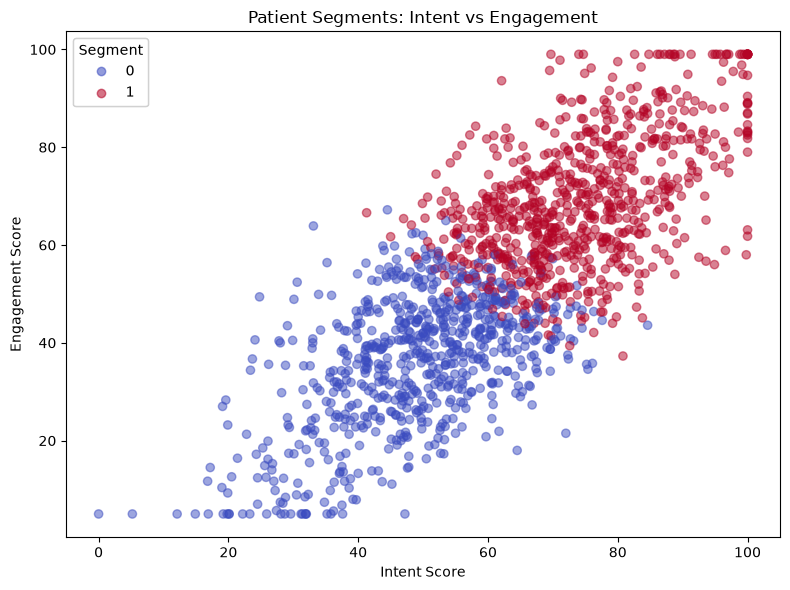

In [32]:
fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(df['intent_score'], df['engagement_score'], 
                      c=df['segment'], cmap='coolwarm', alpha=0.5)
ax.set_xlabel('Intent Score')
ax.set_ylabel('Engagement Score')
ax.set_title('Patient Segments: Intent vs Engagement')
legend1 = ax.legend(*scatter.legend_elements(), title="Segment")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

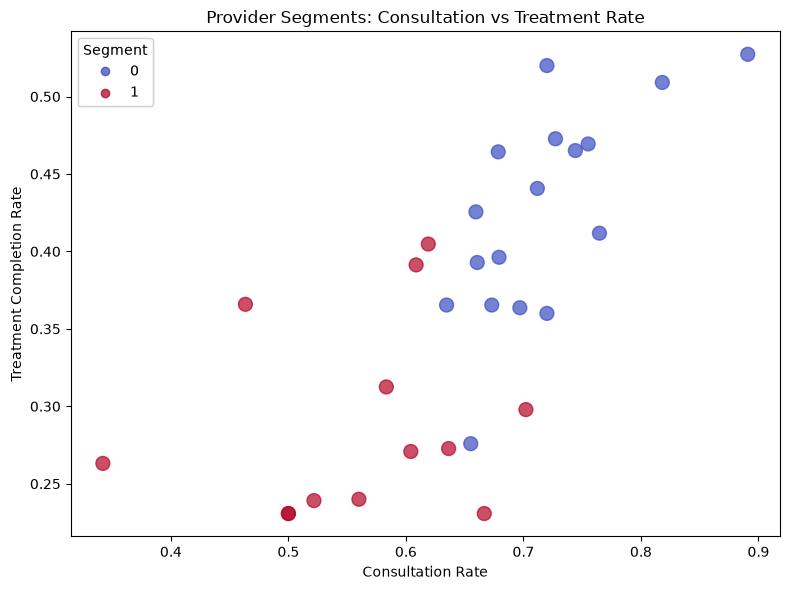

In [35]:
fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(provider_perf['consultation_rate'], provider_perf['treatment_rate'],
                      c=provider_perf['segment'], cmap='coolwarm', s=100, alpha=0.7)
ax.set_xlabel('Consultation Rate')
ax.set_ylabel('Treatment Completion Rate')
ax.set_title('Provider Segments: Consultation vs Treatment Rate')
legend1 = ax.legend(*scatter.legend_elements(), title="Segment")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

## Summary

**Patient segmentation**: Two segments identified (silhouette=0.20 — moderate 
separation, expected for behavioral data). Segment 1 (High-Engagement, n=770) 
converts over 3x higher than Segment 0 (Low-Engagement, n=730) — 55.6% vs 17.3% 
treatment completion. Both segments face high SLA breach rates, but Segment 1 
represents the highest-ROI target for response-speed improvements.

**Provider segmentation**: Two clear tiers identified (silhouette=0.38 — strong 
separation). High-performing providers (n=17) complete treatment at 42.5% vs 
28.8% for underperformers (n=13) — a ~15pp gap consistent with individual 
provider rankings from notebook 02.

**Key recommendation**: Prioritize coordinator effort and SLA improvements on 
high-engagement patients and route case volume toward high-performing providers 
where feasible, while investigating whether underperforming providers' lower 
scores reflect case-mix (more Urgent cases) rather than pure execution gaps.

**Carried forward to final memo**: Both segmentations reinforce the SLA-breach 
finding from notebook 02 as the highest-leverage, most actionable lever across 
patient and provider dimensions.